# Phase Transitions in Noisy Quantum Circuits

## Overview
This notebook investigates the dynamics of Measurement-Induced Phase Transitions (MIPT) and Learnability Transitions in parameterized quantum circuits. However, rather than using projective measurements, this simulation introduces **Amplitude Damping Noise** to drive the transition. 

By utilizing a Matrix Product State (MPS) simulator powered by `quimb` and `PyTorch`, we can simulate circuits well beyond the standard state-vector limits. We track three key metrics as noise scales:
1. **Max Bond Dimension ($\chi$):** A proxy for the maximum entanglement present in the state.
2. **Half-Cut Entanglement Entropy ($S$):** The bipartite entanglement bridging the two halves of the quantum system.
3. **Gradient Variance:** The variance of the parameter-shift gradient, indicating the presence of a Barren Plateau (learnability transition).

In [1]:
from typing import Optional, Callable, Tuple
import numpy as np
import cirq
import torch
import sympy
import quimb as qu
import quimb.tensor as qtn
import matplotlib.pyplot as plt
import os
import tqdm

## 1. MPS Quantum Simulator

To efficiently simulate deep, noisy circuits, we construct a custom simulator that maps `cirq` operations into tensor contractions using `quimb.tensor`. 
* **Unitary Gates:** Applied directly via tensor contraction.
* **Kraus Channels / Mixtures:** Simulated probabilistically (Monte Carlo trajectory approach). The circuit branches into specific classical trajectories based on the Kraus operator probabilities.
* **MPS Compression:** The state is compressed after every operation using Singular Value Decomposition (SVD) with a defined cutoff to keep memory usage bounded.

In [2]:
def simulate(
    circuit: cirq.Circuit,
    verbose: bool = False,
    seed: Optional[int] = None,
    backend: str = "cpu",
    max_bond: Optional[int] = None,
    cutoff: float = 1e-10,
) -> qtn.MatrixProductState:
    """
    Simulates a Cirq quantum circuit using a Matrix Product State (MPS) backend.
    Supports unitary gates, probabilistic mixtures, and specific Kraus channels.
    """
    rng = np.random.RandomState(seed)
    qubits_to_indices = {q: i for i, q in enumerate(sorted(circuit.all_qubits()))}
    nqubits = len(qubits_to_indices)

    # Initialize MPS in the |00...0> state
    mps = qtn.MPS_computational_state("0" * nqubits, dtype="float64", cyclic=False)

    if backend == "gpu":
        for tensor in mps.tensors:
            tensor.modify(
                apply=lambda x: torch.tensor(x, dtype=torch.complex64, device="cuda")
            )

    num_ops = len(list(circuit.all_operations()))
    
    for i, op in enumerate(circuit.all_operations()):
        qubit_indices = [qubits_to_indices[q] for q in op.qubits]
        
        # 1. Pure Unitary Gates
        if cirq.has_unitary(op):
            to_apply = qu.qarray(cirq.unitary(op))
            if backend == "gpu":
                to_apply = torch.tensor(to_apply, dtype=torch.complex64, device="cuda")
            mps.gate_(to_apply, qubit_indices, contract="swap+split", max_bond=max_bond, cutoff=cutoff)

        # 2. Probabilistic Mixtures (e.g., Bit Flip)
        elif cirq.has_mixture(op):
            ps, ops = zip(*cirq.mixture(op))
            sampled_op = ops[rng.choice(range(len(ops)), p=ps)]
            to_apply = qu.qarray(sampled_op)
            
            if backend == "gpu":
                to_apply = torch.tensor(to_apply, dtype=torch.complex64, device="cuda")
            mps.gate_(to_apply, qubit_indices, contract="swap+split", max_bond=max_bond, cutoff=cutoff)

        # 3. General Kraus Channels
        elif cirq.has_kraus(op):
            kraus_ops = cirq.kraus(op)
            probs, states = [], []

            # Calculate probability of each Kraus branch
            for K in kraus_ops:
                K = qu.qarray(K)
                if backend == "gpu":
                    K = torch.tensor(K, dtype=torch.complex64, device="cuda")
                
                temp_mps = mps.copy()
                temp_mps.gate_(K, qubit_indices, contract="swap+split", max_bond=max_bond, cutoff=cutoff)
                probs.append(abs(temp_mps.norm()) ** 2)
                states.append(temp_mps)

            # Normalize and collapse state
            probs = np.array(probs, dtype=float)
            probs /= probs.sum()
            k = rng.choice(len(kraus_ops), p=probs)
            mps = states[k]
            mps.normalize()
        
        # 4. Depolarizing Channels
        elif isinstance(op.gate, cirq.DepolarizingChannel):
            p, q = op.gate.p, len(op.qubits)
            if q == 1:
                paulis = [np.eye(2), cirq.unitary(cirq.X), cirq.unitary(cirq.Y), cirq.unitary(cirq.Z)]
                probs = [1 - p, p/3, p/3, p/3]
                choice = rng.choice(4, p=probs)
                to_apply = qu.qarray(paulis[choice])
            else:
                raise NotImplementedError("Multi-qubit depolarizing not supported.")

            if backend == "gpu":
                to_apply = torch.tensor(to_apply, dtype=torch.complex64, device="cuda")
            mps.gate_(to_apply, qubit_indices, contract="swap+split", max_bond=max_bond, cutoff=cutoff)
            
        else:
            raise ValueError(f"Cannot apply operation {op}.")

        # Compress to bound entanglement and memory
        mps.compress()
        if verbose: print(f"\rOp {i + 1} / {num_ops}", end="")
            
    if verbose: print() 
    return mps

## 2. Ansatz Architecture
We construct a deep "brickwork" circuit utilizing a highly expressive 15-parameter, two-qubit $W$ gate. This alternating even/odd layer structure highly entangles the system, establishing the baseline chaos required to observe a phase transition when noise is subsequently introduced.

In [3]:
class WGate(cirq.Gate):
    """A parameterized 15-rotation 2-qubit unitary gate."""
    def __init__(self, params):
        if len(params) != 15:
            raise ValueError(f"WGate requires exactly 15 parameters, got {len(params)}.")
        self.params = tuple(params)

    def _num_qubits_(self) -> int:
        return 2

    def _is_parameterized_(self) -> bool:
        return cirq.is_parameterized(self.params)

    def _resolve_parameters_(self, resolver: cirq.ParamResolver, recursive: bool):
        resolved_params = [resolver.value_of(p, recursive) for p in self.params]
        return WGate(resolved_params)

    def _decompose_(self, qubits):
        top, bot = qubits
        yield cirq.rz(self.params[0])(top)
        yield cirq.ry(self.params[1])(top)
        yield cirq.rz(self.params[2])(top)
        yield cirq.rz(self.params[3])(bot)
        yield cirq.ry(self.params[4])(bot)
        yield cirq.rz(self.params[5])(bot)
        
        yield cirq.CNOT(bot, top)
        yield cirq.rz(self.params[6])(top)
        yield cirq.ry(self.params[7])(bot)
        yield cirq.CNOT(top, bot)
        yield cirq.ry(self.params[8])(bot)
        yield cirq.CNOT(bot, top)
        
        yield cirq.rz(self.params[9])(top)
        yield cirq.ry(self.params[10])(top)
        yield cirq.rz(self.params[11])(top)
        yield cirq.rz(self.params[12])(bot)
        yield cirq.ry(self.params[13])(bot)
        yield cirq.rz(self.params[14])(bot)

    def _circuit_diagram_info_(self, args: cirq.CircuitDiagramInfoArgs):
        return cirq.protocols.CircuitDiagramInfo(wire_symbols=("W", "W"))

def generate_brickwork(n_qubits, depth=1):
    """Generates an alternating even/odd brickwork circuit architecture."""
    qubits = cirq.LineQubit.range(n_qubits)
    circuit = cirq.Circuit()
    symbols = []
    symbol_counter = 0

    for _ in range(depth):
        # Even Layer
        for i in range(0, n_qubits - 1, 2):
            gate_symbols = sympy.symbols(f'th_{symbol_counter}:{symbol_counter + 15}')
            symbols.extend(gate_symbols)
            circuit.append(WGate(gate_symbols)(qubits[i], qubits[i+1]))
            symbol_counter += 15

        # Odd Layer
        if n_qubits > 2:
            for i in range(1, n_qubits - 1, 2):
                gate_symbols = sympy.symbols(f'th_{symbol_counter}:{symbol_counter + 15}')
                symbols.extend(gate_symbols)
                circuit.append(WGate(gate_symbols)(qubits[i], qubits[i+1]))
                symbol_counter += 15

    return circuit, symbols, qubits

## 3. Observables and Gradient Variance
To track the learnability transition, we calculate the variance of the gradient using the Parameter-Shift Rule. We define a local Pauli-Z observable acting on the central qubit of the chain.

In [4]:
def get_z_expectation(circuit: cirq.Circuit, resolver: dict, target_idx: int) -> float:
    """Calculates the exact Pauli-Z expectation value for a specific qubit index."""
    resolved_circuit = cirq.resolve_parameters(circuit, resolver)
    mps = simulate(resolved_circuit) 
    
    Z = qu.pauli('Z')
    mps_z = mps.copy()
    mps_z.gate_(Z, target_idx)
    
    return float((mps.H @ mps_z).real)

def calculate_gradient_variance(circuit: cirq.Circuit, symbols: list, target_idx: int, n_samples: int) -> float:
    """Calculates the parameter-shift gradient variance over random initializations."""
    target_sym = symbols[2] # Arbitrarily track the 3rd parameter
    shift = np.pi / 2
    grads = []
    
    # We must re-seed locally or rely on global randomness for diverse samples
    for s in range(n_samples):
        base_vals = np.random.uniform(0, 2 * np.pi, len(symbols))
        resolver_base = dict(zip(symbols, base_vals))
        
        # Shift Plus
        res_plus = resolver_base.copy()
        res_plus[target_sym] += shift
        exp_plus = get_z_expectation(circuit, res_plus, target_idx)
        
        # Shift Minus
        res_minus = resolver_base.copy()
        res_minus[target_sym] -= shift
        exp_minus = get_z_expectation(circuit, res_minus, target_idx)
        
        grads.append(0.5 * (exp_plus - exp_minus))
    
    return float(np.var(grads))

def setup_circuit_and_target(circ_function: Callable, n_qubits: int, depth: int) -> Tuple[cirq.Circuit, list, int]:
    """Generates the circuit and identifies the integer index of the middle qubit."""
    circuit, all_symbols, qubits = circ_function(n_qubits, depth)
    qubits_to_indices = {q: i for i, q in enumerate(sorted(circuit.all_qubits()))}
    middle_qubit = qubits[n_qubits // 2]
    target_idx = qubits_to_indices[middle_qubit]

    return circuit, all_symbols, target_idx

## 4. Execution: Sweeping Noise Probabilities
We now execute the core experiment: calculating entanglement (entropy and bond dimension) and trainability (gradient variance) as a function of the amplitude damping probability $p$. This maps the transition from a highly entangled, untrainable phase to a disentangled, trainable phase.

In [5]:
# --- Setup Parameters ---
save_dir = "./data_mipt"
os.makedirs(save_dir, exist_ok=True)

n_qubits = 10
depth = 30
n_samples = 20
nsamp_var = 3  
ps = np.linspace(0, 0.3, 25)
half_cut = n_qubits // 2

# Build the base clean circuit ONCE
circuit, symbols, target_idx = setup_circuit_and_target(generate_brickwork, n_qubits, depth)

# Fix the initial parameters for the static observables
np.random.seed(42)
fixed_params = np.random.rand(len(symbols))
fixed_resolver = dict(zip(symbols, fixed_params))

max_bonds = []
ent_half_cuts = []
vars_n = []

# --- Noise Sweep Loop ---
for p in tqdm.tqdm(ps, desc="Scanning Noise Probabilities"):
    
    noisy_circuit = circuit.with_noise(cirq.amplitude_damp(p))
    resolved_noisy_circuit = cirq.resolve_parameters(noisy_circuit, fixed_resolver)
    
    S_sum = 0.0
    ent_sum = 0.0
    
    # 1. Fixed-Parameter Observables (Entanglement & Max Bond)
    for _ in range(n_samples):
        mps_noise = simulate(resolved_noisy_circuit)
        S_sum += mps_noise.max_bond()
        ent_sum += mps_noise.entropy(half_cut)
        
    max_bonds.append(S_sum / n_samples)
    ent_half_cuts.append(ent_sum / n_samples)

    # 2. Random-Parameter Observables (Grad Variance)f
    var_t = 0.0
    for _ in range(nsamp_var):
        var_t += calculate_gradient_variance(noisy_circuit, symbols, target_idx, n_samples)
        
    vars_n.append(var_t / nsamp_var)

# Save Results
np.save(f"{save_dir}/maxbond_amp_{n_qubits}_{depth}.npy", max_bonds)
np.save(f"{save_dir}/entanglement_amp_{n_qubits}_{depth}.npy", [ent_half_cuts]) 
np.save(f"{save_dir}/variances_prob_avg_{n_qubits}.npy", vars_n)

Scanning Noise Probabilities: 100%|██████████| 25/25 [5:51:59<00:00, 844.80s/it]  


## 5. Execution: Zero-Noise Scaling
To establish a baseline, we evaluate how the gradient variance scales with system size in a completely noiseless environment. Because this is a deep, unstructured brickwork circuit, we expect to see an exponentially vanishing gradient—the classic barren plateau.

In [6]:
print("\nRunning Zero-Noise Scaling Variance...")
vars_scaling = []

for nq in tqdm.tqdm(range(5, 20), desc="Scaling Qubits"):
    circ_scale, syms_scale, tgt_scale = setup_circuit_and_target(generate_brickwork, nq, depth)
    var_n = calculate_gradient_variance(circ_scale, syms_scale, tgt_scale, n_samples)
    vars_scaling.append(var_n)

np.save(f"{save_dir}/var_withoutp.npy", vars_scaling)
print("Simulation Complete. Data saved to:", save_dir)


Running Zero-Noise Scaling Variance...


Scaling Qubits: 100%|██████████| 15/15 [4:20:30<00:00, 1042.02s/it]

Simulation Complete. Data saved to: ./data_mipt


## 6. Visualization of the Phase Transition

Finally, we plot the results of our noise sweep. 

1. **Entanglement vs. Variance:** We use a dual-axis plot to visualize how the bipartite entanglement entropy (linear scale) and the gradient variance (logarithmic scale) decay simultaneously as the amplitude damping probability $p$ increases. 
2. **Max Bond Dimension:** We plot the maximum bond dimension $\chi$ required by the MPS, which serves as a proxy for the total bipartite entanglement and classical simulation complexity.

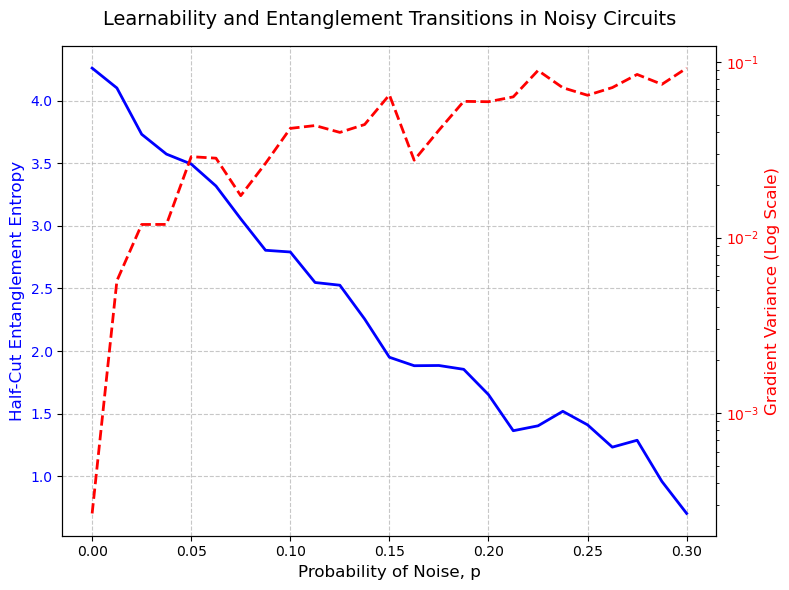

In [7]:
import matplotlib.pyplot as plt

# ==========================================
# Figure 1: Entanglement and Variance vs. Noise
# ==========================================
fig, ax1 = plt.subplots(figsize=(8, 6))

# Left y-axis plot (Entanglement)
ax1.plot(ps, ent_half_cuts, label='Entanglement', color='blue', linewidth=2)
ax1.set_xlabel('Probability of Noise, p', fontsize=12)
ax1.set_ylabel('Half-Cut Entanglement Entropy', color='blue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, linestyle='--', alpha=0.7)

# Right y-axis plot (Variance) sharing the same x-axis
ax2 = ax1.twinx()
ax2.plot(ps, vars_n, linestyle='--', label=r'$\text{Var}\partial_\mu C$', color='red', linewidth=2)
ax2.set_ylabel(r'Gradient Variance (Log Scale)', color='red', fontsize=12)

# Set right axis to logarithmic scale to detect the Barren Plateau
ax2.set_yscale('log')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Learnability and Entanglement Transitions in Noisy Circuits', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(f"{save_dir}/Noise_ent_var.pdf", dpi=300)
plt.show()


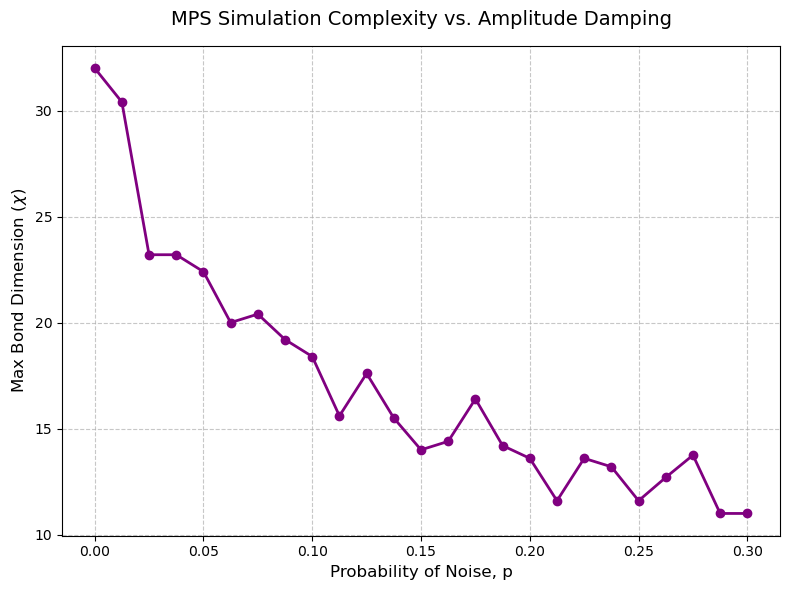

In [8]:

# ==========================================
# Figure 2: Max Bond Dimension vs. Noise
# ==========================================
plt.figure(figsize=(8, 6))

plt.plot(ps, max_bonds, color='purple', marker='o', linestyle='-', linewidth=2, markersize=6)
plt.xlabel('Probability of Noise, p', fontsize=12)
plt.ylabel(r'Max Bond Dimension ($\chi$)', fontsize=12)
plt.title('MPS Simulation Complexity vs. Amplitude Damping', fontsize=14, pad=15)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(f"{save_dir}/Noise_max_bond.pdf", dpi=300)
plt.show()

## Acknowledgments & Contributions

The foundation of this tensor network simulation codebase relies on a collaborative effort. I would like to explicitly acknowledge the following contributions:
* **Ryan La Rose:** Authored the initial, foundational tensor network simulation framework for quantum circuits.
* **Harkirat Verma:** Adapted and expanded the initial framework specifically for analyzing Quantum Convolutional Neural Networks (QCNNs).
* **[Bhanu Prakash]:** Adapted the architecture to support deep, highly expressive Brickwork circuits.